# **Imports**

In [1]:

from earthscape.constants import VERSION, ASSETS_DIR, MODEL_DIR
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats

from earthscape.analysis.data_processing import parse_input_label, parse_features, spatial_support

import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"



# **Setup**

In [2]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/classification'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)


# path to areas CSV
areas_path = glob.glob(r'../data/*areas.csv')[0]


# **Global Performance**

## *Compile Experiments*

In [ ]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# initialize df
df_single = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_single.loc[idx, 'model'] = model_name
    df_single.loc[idx, 'input'] = modalities
    df_single.loc[idx, id.columns] = id.values
    df_single.loc[idx, cd.columns] = cd.values

df_single.head()

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
0,resnet18,dem,0.602931,0.735997,0.643086,0.884792,0.688748,0.854632,0.434013,0.547115,0.477664,0.738261,0.517997,0.812314
1,resnet18,ep-101,0.605707,0.702741,0.646793,0.877772,0.686281,0.858445,0.473424,0.556099,0.505843,0.768841,0.535200,0.819754
2,resnet18,ep-11,0.607223,0.681256,0.635482,0.884064,0.683484,0.862072,0.371203,0.432189,0.361962,0.633331,0.414121,0.782924
3,resnet18,ep-201,0.597582,0.697645,0.639191,0.878450,0.686582,0.856771,0.469866,0.571288,0.505366,0.778119,0.521125,0.813337
4,resnet18,ep-21,0.637124,0.687794,0.652460,0.886925,0.699768,0.868025,0.402375,0.367022,0.369382,0.660956,0.435184,0.825335


In [ ]:
##################################################
# Compile Global Performance Metrics - Multi-scale
##################################################

# initialize df
df_ms = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_ms.loc[idx, 'model'] = model_name
    df_ms.loc[idx, 'input'] = modalities
    df_ms.loc[idx, id.columns] = id.values
    df_ms.loc[idx, cd.columns] = cd.values

df_ms.head()

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
0,resnet18,ep-ms,0.649184,0.710851,0.670324,0.903797,0.719905,0.877511,0.528758,0.553824,0.519121,0.787620,0.542365,0.843378
1,resnet18,plc-ms,0.633666,0.754978,0.676541,0.882308,0.706658,0.855655,0.480477,0.714206,0.563645,0.821300,0.587493,0.808594
2,resnet18,prc-ms,0.653658,0.701854,0.664650,0.905623,0.727501,0.883650,0.551286,0.666225,0.599876,0.799561,0.629986,0.870350
3,resnet18,s-ms,0.632823,0.737827,0.672458,0.884698,0.709102,0.874907,0.502245,0.671046,0.566459,0.797132,0.607162,0.845145
4,resnet18,sds-ms,0.612968,0.714777,0.642842,0.876027,0.681086,0.857236,0.495645,0.654411,0.554050,0.741906,0.572481,0.838077


In [ ]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# initialize df
df_mm = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]
    if modalities == 'dem':
        modalities = 'dem+rgb'

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_mm.loc[idx, 'model'] = model_name
    df_mm.loc[idx, 'input'] = modalities
    df_mm.loc[idx, id.columns] = id.values
    df_mm.loc[idx, cd.columns] = cd.values

df_mm.head()

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
0,resnet18,dem+rgb,0.596312,0.632027,0.601625,0.863707,0.656107,0.851190,0.404380,0.446812,0.403065,0.639524,0.428877,0.767578
1,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
2,resnet18,ep-ms+prc-ms,0.656010,0.685922,0.667761,0.918376,0.739230,0.887649,0.511714,0.670563,0.576805,0.844358,0.626916,0.864955
3,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
4,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326


In [11]:
##################################################
# Compile All Global Experiments
##################################################

# compile data & save...
df = pd.concat([df_single, df_ms, df_mm])
df.sort_values(['model', 'macro_f1 (id)'], ascending=[True, False], inplace=True)
df.reset_index(drop=True, inplace=True)
df.to_csv(os.path.join(assets_dir, 'compiled_global.csv'), index=False)

df.head()

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
0,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
1,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
2,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326
3,resnet18,prc-ms+s-ms,0.646198,0.716703,0.677398,0.914787,0.722433,0.887556,0.533018,0.674506,0.591428,0.814392,0.635560,0.869792
4,resnet18,plc-ms,0.633666,0.754978,0.676541,0.882308,0.706658,0.855655,0.480477,0.714206,0.563645,0.821300,0.587493,0.808594


## *Visualizations*

### Modality Rankings

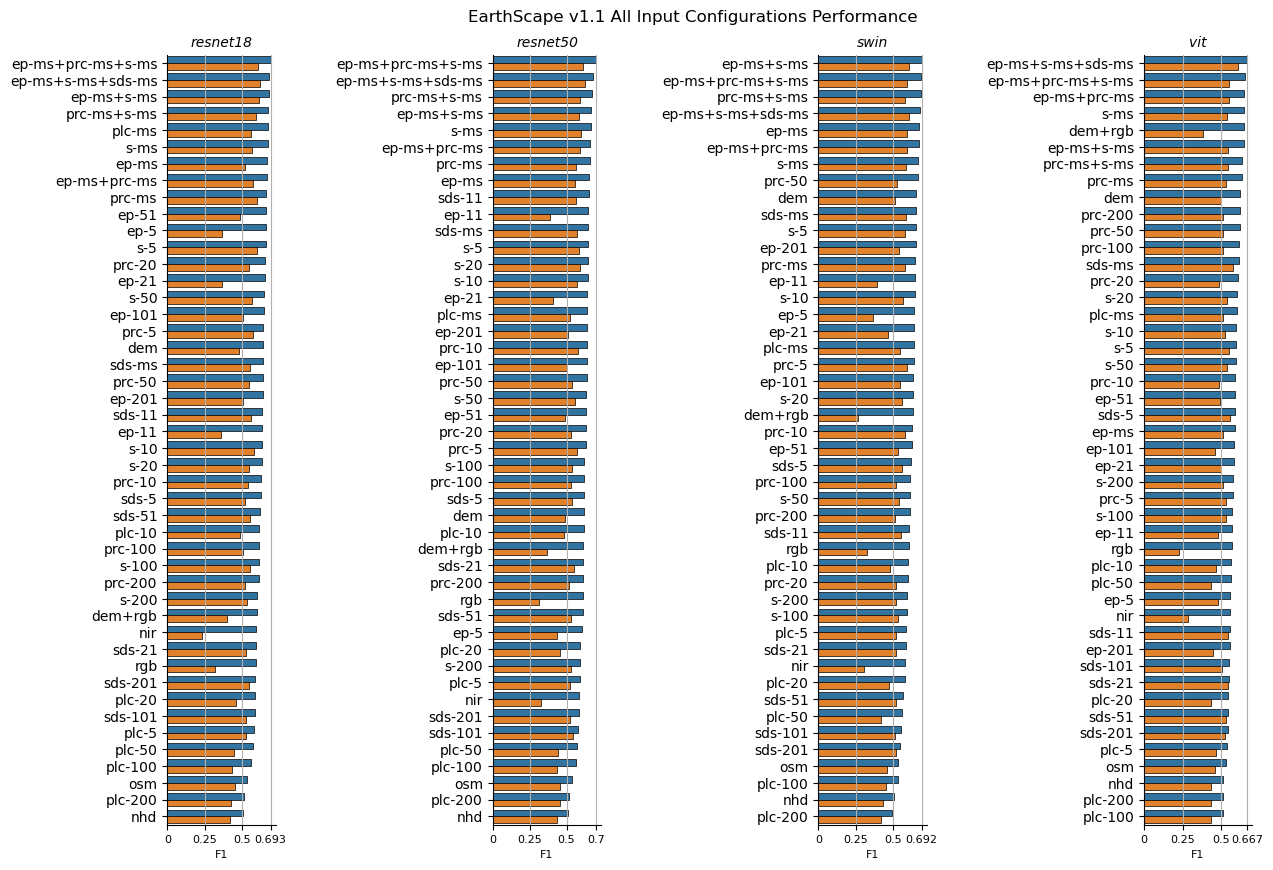

In [ ]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_all = pd.read_csv(single_path)

# metric to plot...
metric = 'f1'
metric_label = 'F1'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models), 10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

idx = 0
for m in df_all['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_all[df_all['model'] == m].copy()
        df.sort_values(f"macro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"macro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"macro_{metric} (id)", f"macro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} All Input Configurations Performance", y=0.925)

plt.savefig(f"{assets_dir}/rankings.svg", format='svg', bbox_inches='tight')
plt.show()

### Scale Sensitivity

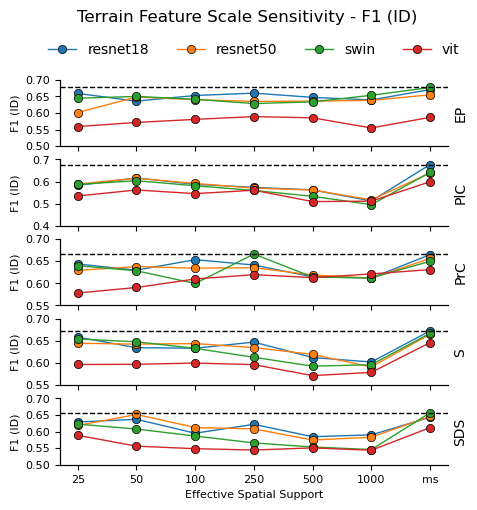

In [16]:
#############################################
# Terrain Feature Scale-Sensitivity - In-domain
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'f1'
metric_label = 'F1'


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model'].unique():
        df = subset[subset['model'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"macro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    max_val = subset[f"macro_{metric} (id)"].max()
    ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(f"{metric_label} (ID)", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xticks(ax[4].get_xticks())
ax[4].set_xticklabels(ax[4].get_xticklabels(), fontsize=8)
ax[4].set_xlabel('Effective Spatial Support', fontsize=8)
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Terrain Feature Scale Sensitivity - {metric_label} (ID)", y=1.02)

# plt.savefig(f"{assets_dir}/scale_sensitivity.svg", format='svg', bbox_inches='tight')
plt.show()

### Cross-domain Robustness

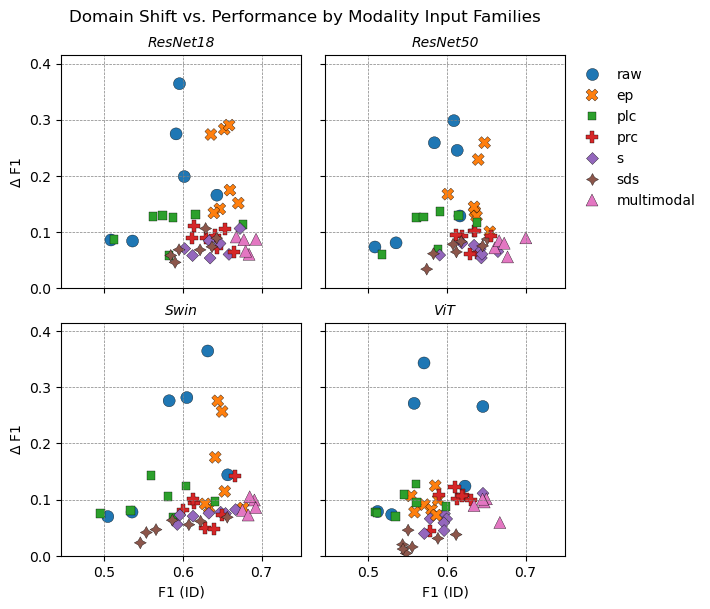

In [ ]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'f1'
metric_label = 'F1'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled[f"delta {metric}"] = df_compiled[f"macro_{metric} (id)"] - df_compiled[f"macro_{metric} (cd)"]


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"macro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"macro_{metric} (id)"].max() + 0.05
ymax = df_compiled[f"delta {metric}"].max() + 0.05

# iterate over model architectures...
models = df_compiled['model'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"macro_{metric} (id)", y=f"delta {metric}", hue='family', style='family', s=75, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(0, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ylab = r'$\Delta$ ' + f"{metric_label}"
    ax[idx].set_ylabel(ylab)
    if 'resnet' in m:
        name = 'ResNet' + m[-2:]
        ax[idx].set_title(name, style='italic', fontsize=10)
    elif 'vit' in m:
        ax[idx].set_title('ViT', style='italic', fontsize=10)
    elif 'swin' in m:
        ax[idx].set_title('Swin', style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Domain Shift vs. Performance by Modality Input Families', y=0.95)

# plt.savefig(os.path.join(assets_dir, 'delta_vs_id_f1.svg'), format='svg', bbox_inches='tight')
plt.show()

### Performance vs. MMD

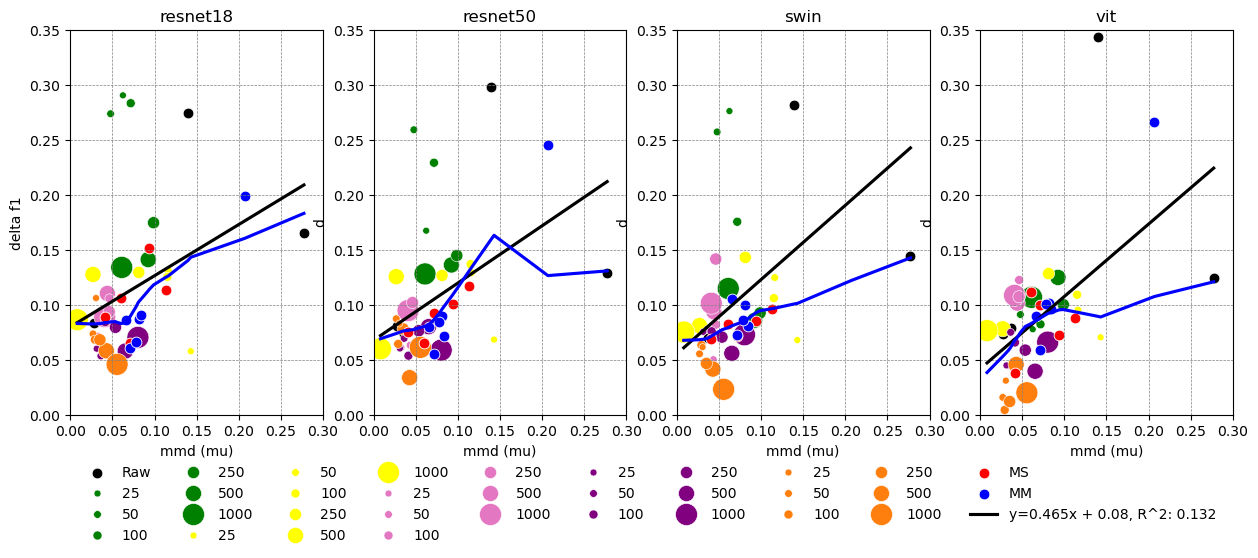

In [5]:
#############################################
# Performance vs. MMD
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

# metric to plot...
metric = 'd'


# ##### pre-processing...
df_compiled = pd.read_csv(compiled_path)
df_compiled[["family", "spatial support"]] = df_compiled["input"].apply(parse_input_label)
df_mmd = pd.read_csv(mmd_path)
# df_mmd['input'] = df_mmd['input'].apply(lambda x: str(x).lower().replace(' ', '-'))
df = pd.merge(left=df_compiled, right=df_mmd, left_on='input', right_on='input', how='inner')


##### calculate regression & plot...
fig, ax = plt.subplots(ncols=4, figsize=(15,5))

for idx, m in enumerate(df['model'].unique()):
    mask = df['model'] == m
    subset = df[mask].copy()

    subset['d'] = subset['macro_f1 (id)'] - subset['macro_f1 (cd)']
    subset['dr'] = (subset['macro_f1 (id)'] - subset['macro_f1 (cd)']) / subset['macro_f1 (id)'] * 100

    res = stats.linregress(subset["mmd (mu)"], subset[f"{metric}"])
    r2 = res.rvalue**2
    label = f"y={round(res.slope, 3)}x + {round(res.intercept, 3)}, R^2: {round(r2.item(), 3)}"

    sns.scatterplot(data=subset[subset['family'] == 'raw'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='k', s=60, label='Raw')

    sns.scatterplot(data=subset[subset['family'] == 'ep'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='green', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'plc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='yellow', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'prc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:pink', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 's'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='purple', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'sds'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:orange', size='spatial support', sizes=(25, 250))

    sns.scatterplot(data=subset[subset['family'] == 'multi-scale'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='red', s=60, label='MS')
    sns.scatterplot(data=subset[subset['family'] == 'multimodal'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='blue', s=60, label='MM')

    x = sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", robust=False, ci=False, label=label, color='k', scatter=False, ax=ax[idx])
    sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", lowess=True, robust=False, ci=False, color='blue', scatter=False, ax=ax[idx])


    ax[idx].set_title(f"{m}")
    ax[idx].set_ylim(0, 0.35)
    ax[idx].set_xlim(0, 0.3)

    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')

for axes in ax:
    axes.legend().remove()
ax[0].legend(loc='upper left', bbox_to_anchor=(0,-0.1), frameon=False, ncols = 10)
ax[0].set_ylabel('delta f1')

plt.savefig(f"{ASSETS_DIR}/baselines/classification/delta_vs_mmd_clf.svg", format='svg', bbox_inches='tight')
plt.show()

# **Class-wise Performance**

## *Compile Experiments*

In [21]:
##################################################
# Compile Class-wise Performance Metrics - Single
##################################################

# initialize df
df_single = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_single = pd.concat([df_single, df], ignore_index=True, axis=0)
    df_single.loc[idx:idx+len(df), 'model'] = model_name
    df_single.loc[idx:idx+len(df), 'input'] = modalities
    df_single.loc[idx:idx+len(df), df_single.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_single.sort_values(['model', 'input'], inplace=True)
df_single.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_single[int_cols] = df_single[int_cols].astype(int)

df_single.head()

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571,538,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435,567,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950,1010,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845,1331,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13,28,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6,0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61,210,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77,2,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749,805,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456,763,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901


In [22]:
##################################################
# Compile Class-wise Performance Metrics - Multiscale
##################################################

# initialize df
df_ms = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_ms = pd.concat([df_ms, df], ignore_index=True, axis=0)
    df_ms.loc[idx:idx+len(df), 'model'] = model_name
    df_ms.loc[idx:idx+len(df), 'input'] = modalities
    df_ms.loc[idx:idx+len(df), df_ms.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_ms.sort_values(['model', 'input'], inplace=True)
df_ms.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_ms[int_cols] = df_ms[int_cols].astype(int)

df_ms.head()

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,ep-ms,af1,0.166701,571,641,0.678627,0.761821,0.717822,0.852539,0.807584,0.777344,435,363,0.691460,0.577011,0.629073,0.799860,0.697051,0.807292
1,resnet18,ep-ms,Qal,0.560404,950,918,0.823529,0.795789,0.809422,0.844297,0.903840,0.768229,845,1058,0.663516,0.830769,0.737782,0.742563,0.781220,0.675130
2,resnet18,ep-ms,Qaf,0.061369,13,63,0.047619,0.230769,0.078947,0.889388,0.126165,0.954427,6,17,0.058824,0.166667,0.086957,0.752288,0.021241,0.986328
3,resnet18,ep-ms,Qat,0.441588,61,72,0.430556,0.508197,0.466165,0.910308,0.396106,0.953776,77,201,0.218905,0.571429,0.316547,0.864148,0.293067,0.876302
4,resnet18,ep-ms,Qc,0.464265,749,790,0.853165,0.899866,0.875893,0.957726,0.960449,0.875651,456,281,0.629893,0.388158,0.480326,0.744528,0.587996,0.750651


In [23]:
##################################################
# Compile Class-wise Performance Metrics - Multimodal
##################################################

# initialize df
df_mm = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in mm_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_mm = pd.concat([df_mm, df], ignore_index=True, axis=0)
    df_mm.loc[idx:idx+len(df), 'model'] = model_name
    df_mm.loc[idx:idx+len(df), 'input'] = modalities
    df_mm.loc[idx:idx+len(df), df_mm.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_mm.sort_values(['model', 'input'], inplace=True)
df_mm.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_mm[int_cols] = df_mm[int_cols].astype(int)

df_mm.head()

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem+rgb,af1,0.364054,571,515,0.722330,0.651489,0.685083,0.837819,0.792015,0.777344,435,979,0.295199,0.664368,0.408769,0.540670,0.329301,0.455729
1,resnet18,dem+rgb,Qal,0.433651,950,1123,0.729297,0.862105,0.790159,0.764169,0.841296,0.716797,845,401,0.586035,0.278107,0.377207,0.524012,0.552495,0.494792
2,resnet18,dem+rgb,Qaf,0.083251,13,59,0.050847,0.230769,0.083333,0.869539,0.067017,0.957031,6,0,0.000000,0.000000,0.000000,0.338671,0.003252,0.996094
3,resnet18,dem+rgb,Qat,0.454679,61,35,0.257143,0.147541,0.187500,0.877455,0.227220,0.949219,77,0,0.000000,0.000000,0.000000,0.677728,0.117256,0.949870
4,resnet18,dem+rgb,Qc,0.633571,749,701,0.841655,0.787717,0.813793,0.907991,0.914234,0.824219,456,724,0.466851,0.741228,0.572881,0.745005,0.523184,0.671875


In [25]:
##################################################
# Compile All Class-wise Experiments
##################################################

# compile data...
df = pd.concat([df_single, df_ms, df_mm])
df.reset_index(drop=True, inplace=True)
df.to_csv(os.path.join(assets_dir, 'compiled_class.csv'), index=False)

df.head(14)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571,538,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435,567,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950,1010,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845,1331,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13,28,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6,0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61,210,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77,2,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749,805,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456,763,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901
5,resnet18,dem,Qca,0.271758,432,514,0.686770,0.817130,0.746300,0.929933,0.864910,0.843750,249,242,0.636364,0.618474,0.627291,0.888371,0.634261,0.880859
6,resnet18,dem,Qr,0.387985,1433,1497,0.943220,0.985345,0.963823,0.930318,0.994803,0.930990,1511,1536,0.983724,1.000000,0.991795,0.803058,0.993830,0.983724
7,resnet18,ep-101,af1,0.142561,571,692,0.650289,0.788091,0.712589,0.841750,0.795029,0.763672,435,401,0.618454,0.570115,0.593301,0.784572,0.672870,0.778646
8,resnet18,ep-101,Qal,0.335206,950,1121,0.740410,0.873684,0.801545,0.809657,0.881219,0.732422,845,1304,0.587423,0.906509,0.712890,0.758936,0.818864,0.598307
9,resnet18,ep-101,Qaf,0.157042,13,32,0.093750,0.230769,0.133333,0.853376,0.085173,0.974609,6,7,0.000000,0.000000,0.000000,0.732244,0.010172,0.991536


## *Visualizations*

### Probability vs. Class-area Proportion

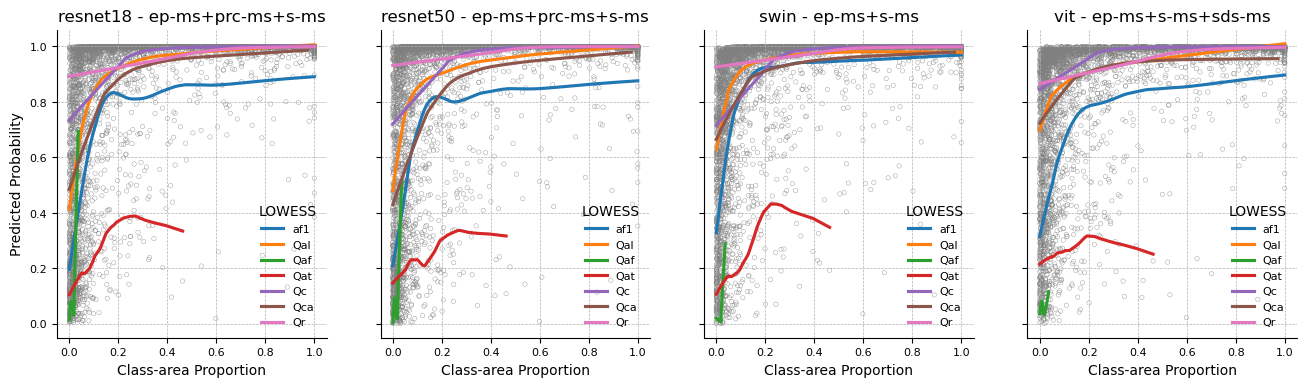

In [47]:
#############################################
# Model Prediction vs. Class Area in Sample
#############################################

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# model-best input dictionary
model_input_dict = {
    'resnet18': 'ep-ms+prc-ms+s-ms', 
    'resnet50': 'ep-ms+prc-ms+s-ms',
    'swin': 'ep-ms+s-ms',
    'vit': 'ep-ms+s-ms+sds-ms'
    }

# root directory containing all experiments
exp_root = r'../experiments/baselines/classification'


##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)

# set up figure...one subplot for each model
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(16,4))

# iterate through each model experiment...
idx = 0
for model, input in model_input_dict.items():

    exp_dir = glob.glob(os.path.join(exp_root, "**", f"*{model}*{input}*"))
    exp_dir = [d for d in exp_dir if 'variance' not in d][0]

    path = os.path.join(exp_dir, "predictions_id.csv")
    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    df = preds.merge(right=areas, how='left', on='patch_id', suffixes=['', '_area'])    # merge with area proportions
    df.set_index('patch_id', drop=True, inplace=True)                                   # reset index using patch_id

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    # iterate through each class...
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()     # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]       # only process patches with class presence

        # plot lowess curve...
        sns.regplot(ax=ax[idx], data=df2, x=a, y=p, lowess=True, scatter=False, label=p)
        sns.scatterplot(ax=ax[idx], data=df2, x=a, y=p, edgecolor='0.5', s=10, facecolor='none')

    # customize plot...
    ax[idx].legend(loc='lower right', bbox_to_anchor=(1, 0), frameon=False, fontsize=8, title='LOWESS')
    ax[idx].set_title(f"{model} - {input}")
    ticks = np.arange(0, 1.01, 0.2)
    ax[idx].set_xlabel('Class-area Proportion')
    ax[idx].set_xticks(ticks)
    ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
    ax[idx].set_yticks(ticks)
    ax[idx].set_yticklabels([])
    ax[idx].set_ylabel('')
    ax[idx].grid(axis='both', linewidth=0.5, linestyle='--')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

    idx += 1

# set y axis for first plot...
ax[0].set_ylabel('Predicted Probability')
ax[0].set_yticks(ticks)
ax[0].set_yticklabels([str(round(s, 1)) for s in ticks], fontsize=8)

plt.savefig(os.path.join(assets_dir, 'prob_vs_area.svg'), format='svg', bbox_inches='tight')
plt.show()

### Class Performance Heatmap

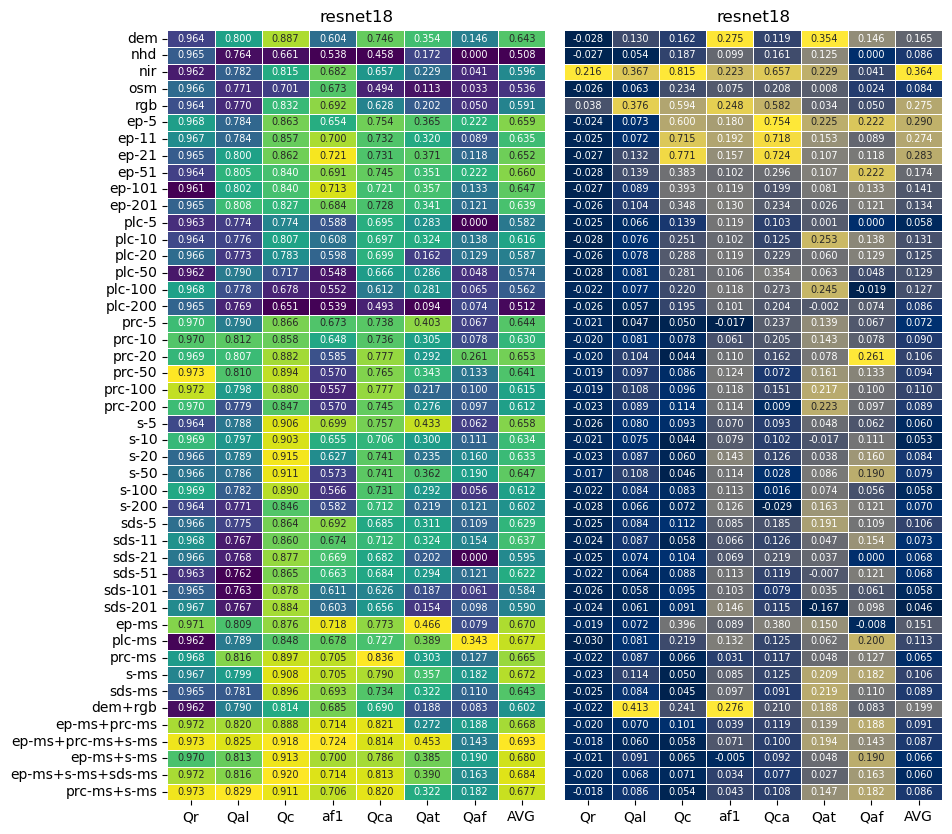

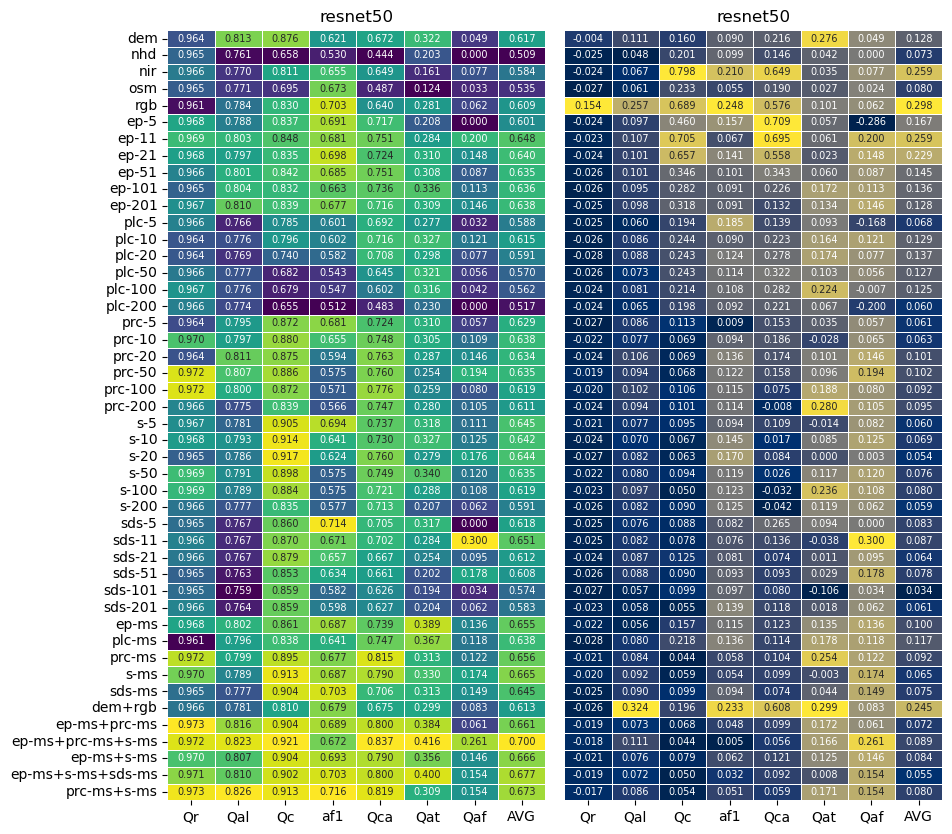

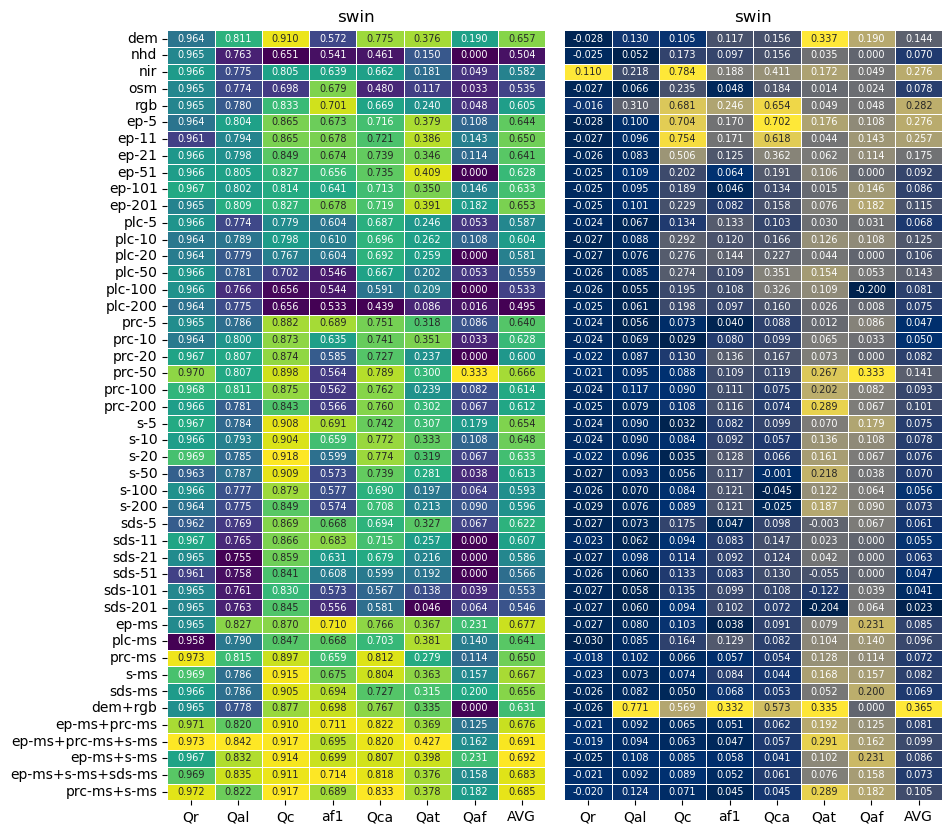

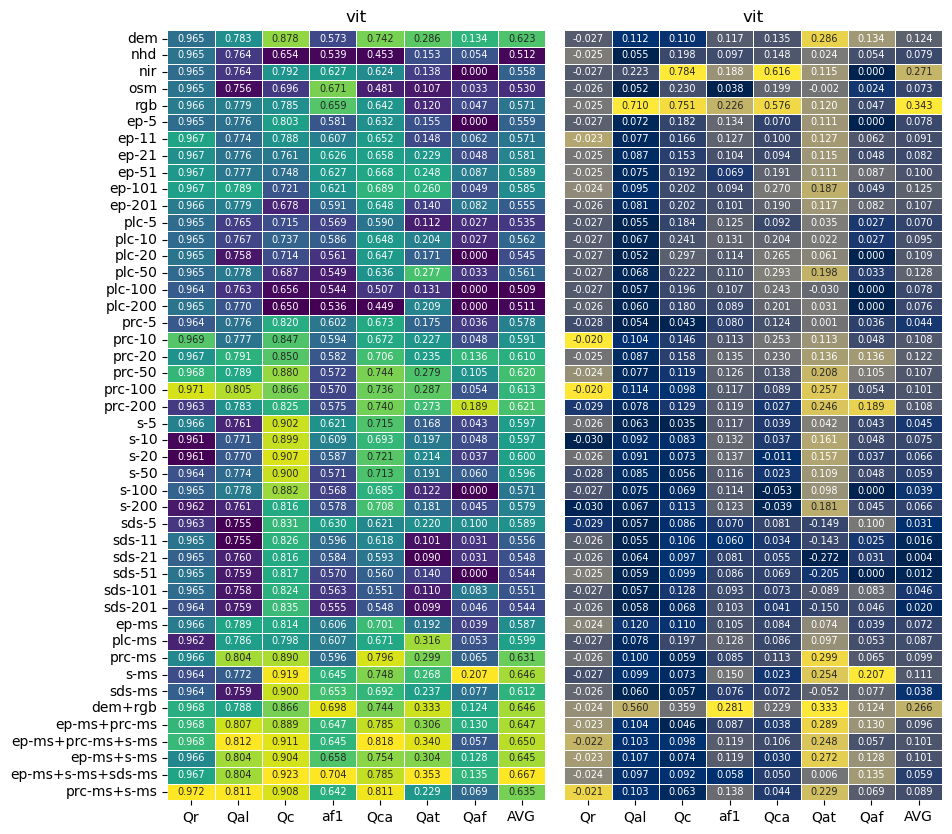

In [ ]:
#############################################
# Class-level Heatmap with Macro-Average
#############################################

# path to compiled class metrics
class_path = os.path.join(f"{assets_dir}/compiled_class.csv")

# metric to use for heatmap
metric = "f1"


##### pre-processing & plotting...
df = pd.read_csv(class_path)

# iterate through each model separately...
for model in df['model'].unique():

    subset = df[df["model"] == model].copy()

    # parse data in fixed order...
    subset[["family", "spatial support"]] = subset["input"].apply(parse_input_label)

    # fixed orders for plotting...
    class_order = ["Qr", "Qal", "Qc", "af1", "Qca", "Qat", "Qaf"]
    heatmap_order = class_order + ["AVG"]
    family_rank = {"raw": 0, "ep": 1, "plc": 2, "prc": 3, "s": 4, "sds": 5, "multi-scale": 6, "multimodal": 7}
    support_families = ["ep", "plc", "prc", "s", "sds"]

    # map orders to dataframe subset...
    subset["family_rank"] = subset["family"].map(family_rank)
    subset["support_sort"] = np.where(subset["family"].isin(support_families), pd.to_numeric(subset["spatial support"], errors="coerce"), np.nan)
    subset["alpha_sort"] = subset["input"].astype(str).str.lower()
    subset = subset.sort_values(by=["family_rank", "support_sort", "alpha_sort"], na_position="last")
    row_order = subset["input"].drop_duplicates()

    subset['delta'] = subset[f"{metric} (id)"] - subset[f"{metric} (cd)"]


    # create heatmap dataframe by pivoting...
    id_heatmap = subset.pivot(index="input", columns="class", values=f"{metric} (id)").loc[row_order, class_order]
    id_heatmap['AVG'] = id_heatmap[class_order].mean(axis=1)
    id_norm = (id_heatmap - id_heatmap.min(axis=0)) / (id_heatmap.max(axis=0) - id_heatmap.min(axis=0))


    delta_heatmap = subset.pivot(index="input", columns="class", values="delta").loc[row_order, class_order]
    delta_heatmap['AVG'] = delta_heatmap[class_order].mean(axis=1)
    delta_norm = (delta_heatmap - delta_heatmap.min(axis=0)) / (delta_heatmap.max(axis=0) - delta_heatmap.min(axis=0))


    ##### plot heatmap...
    fig, ax = plt.subplots(ncols=2, figsize=(10,10))

    sns.heatmap(
        id_norm[heatmap_order],
        annot=id_heatmap[heatmap_order],
        fmt=".3f", cmap="viridis", linewidths=0.5, annot_kws={'fontsize': 7}, cbar=False, 
        ax=ax[0]
        )
    
    sns.heatmap(
        delta_norm[heatmap_order],
        annot=delta_heatmap[heatmap_order],
        fmt=".3f", cmap="cividis", linewidths=0.5, annot_kws={'fontsize': 7}, cbar=False, 
        ax=ax[1]
        )

    for a in ax:
        a.set_xlabel("")
        a.set_ylabel("")
        a.set_title(model)
    
    ax[1].set_yticks([])

    # ax.set_xlabel("")
    # ax.set_ylabel("")
    # ax.set_title(f"{model} - column-normalized {metric}")

    plt.subplots_adjust(wspace=0.05)

    plt.savefig(os.path.join(assets_dir, f"class_heatmap_{model}.svg"), format='svg', bbox_inches='tight')
    plt.show()

    # break

Index(['model', 'input', 'class', 'decision threshold', 'ground truth (id)',
       'predicted (id)', 'precision (id)', 'recall (id)', 'f1 (id)',
       'auroc (id)', 'ap (id)', 'accuracy (id)', 'ground truth (cd)',
       'predicted (cd)', 'precision (cd)', 'recall (cd)', 'f1 (cd)',
       'auroc (cd)', 'ap (cd)', 'accuracy (cd)', 'family', 'spatial support',
       'family_rank', 'support_sort', 'alpha_sort'],
      dtype='str')

# **Correlations**

## *Dataset Class Imbalance*

In [ ]:
#############################################
# In-domain Performance vs. Class Frequency
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_class.csv')
stats_path = glob.glob(r'../assets/data_eda/*imbalance_metrics.csv')[0]

response = 'f1 (id)'
predictor = 'N_eff'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_stats = pd.read_csv(stats_path)
df = pd.merge(left=df_compiled, right=df_stats, how='inner', on='class')


df_corr = pd.DataFrame({
    "r2": df.groupby(['model', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby(['model', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby(['model', 'input']).apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby(['model', 'input']).apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    })

df_corr_avg = df_corr.groupby('model').mean()
df_corr_avg.to_csv(f"{assets_dir}/correlation_n_effective.csv")
df_corr_avg.head()

,r2,pcc,srcc,krcc
model,,,,
resnet18,0.927216,0.962795,0.933230,0.830228
resnet50,0.928990,0.963757,0.930901,0.828157
swin,0.925719,0.961997,0.929348,0.824017
vit,0.942366,0.970651,0.943323,0.853002


## *Intra-patch Spatial Support*

In [120]:
#############################################
# Correlation of Performance vs. Spatial Support
#############################################

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# model-best input dictionary
model_input_dict = {
    'resnet18': 'ep-ms+prc-ms+s-ms', 
    'resnet50': 'ep-ms+prc-ms+s-ms',
    'swin': 'ep-ms+s-ms',
    'vit': 'ep-ms+s-ms+sds-ms'
    }

# root directory containing all experiments
exp_root = r'../experiments/baselines/classification'


##### pre-process & calculate correlations....
# read areas dataframe 
areas = pd.read_csv(areas_path)

# initialize dataframe to hold correlations
df_corr = pd.DataFrame(columns=['model', 'input', 'r2', 'pcc', 'srcc', 'krcc'])

# iterate through each model experiment...
idx = 0
for model, input in model_input_dict.items():

    exp_dir = glob.glob(os.path.join(exp_root, "**", f"*{model}*{input}*"))
    exp_dir = [d for d in exp_dir if 'variance' not in d][0]

    path = os.path.join(exp_dir, "predictions_id.csv")
    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    df = preds.merge(right=areas, how='left', on='patch_id', suffixes=['', '_area'])    # merge with area proportions
    df.set_index('patch_id', drop=True, inplace=True)                                   # reset index using patch_id

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    corr = pd.DataFrame(columns=['r2', 'pcc', 'srcc', 'krcc'])

    # iterate through each class...
    idx2 = 0
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()     # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]       # only process patches with class presence

        corr.loc[idx2, 'r2'] = df2[a].corr(df2[p], method='pearson')**2
        corr.loc[idx2, 'pcc'] = df2[a].corr(df2[p], method='pearson')
        corr.loc[idx2, 'srcc'] = df2[a].corr(df2[p], method='spearman')
        corr.loc[idx2, 'krcc'] = df2[a].corr(df2[p], method='kendall')

        idx2 += 1

    df_corr.loc[idx, 'model'] = model
    df_corr.loc[idx, 'input'] = input
    df_corr.loc[idx, 'r2'] = corr['r2'].mean()
    df_corr.loc[idx, 'pcc'] = corr['pcc'].mean()
    df_corr.loc[idx, 'srcc'] = corr['srcc'].mean()
    df_corr.loc[idx, 'krcc'] = corr['krcc'].mean()

    idx += 1

df_corr.to_csv(f"{assets_dir}/correlation_area.csv", index=False)
df_corr.head()

,model,input,r2,pcc,srcc,krcc
0,resnet18,ep-ms+prc-ms+s-ms,0.180406,0.413832,0.584654,0.408967
1,resnet50,ep-ms+prc-ms+s-ms,0.167928,0.397502,0.505219,0.34539
2,swin,ep-ms+s-ms,0.154004,0.366392,0.509916,0.360494
3,vit,ep-ms+s-ms+sds-ms,0.136426,0.340267,0.489232,0.350623


## *Inter-region Geographic Robustness*

In [ ]:
###################################
# Performance Degradation vs. MMD
###################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

metric = 'macro_f1'
response = 'delta'
predictor = 'mmd (mu)'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_mmd = pd.read_csv(mmd_path)
df = pd.merge(left=df_compiled, right=df_mmd, how='inner', on='input')
df['delta'] = df[f"{metric} (id)"] - df[f"{metric} (cd)"]

df_corr = pd.DataFrame({
    "r2": df.groupby("model").apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby("model").apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby("model").apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby("model").apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    })

df_corr.to_csv(f"{assets_dir}/correlation_mmd.csv")
df_corr.head()

,r2,pcc,srcc,krcc
model,,,,
resnet18,0.131768,0.362998,0.405138,0.294949
resnet50,0.201994,0.449437,0.483136,0.335354
swin,0.235436,0.485217,0.539130,0.375758
vit,0.314878,0.561140,0.543083,0.375758


# **Model Variance**

## *Global Variance - Best Inputs*

In [11]:
#############################################
# Model Performance Variance
#############################################

# model-best input dictionary
model_input_list = [
    ('resnet18', 'ep-51'),
    ('resnet18', 'plc-ms'),
    ('resnet18', 'ep-ms+prc-ms+s-ms'),

    ('resnet50', 'sds-11'),
    ('resnet50', 's-ms'),
    ('resnet50', 'ep-ms+prc-ms+s-ms'),

    ('swin', 'prc-50'),
    ('swin', 'ep-ms'),
    ('swin', 'ep-ms+s-ms'),

    ('vit', 'dem'),
    ('vit', 's-ms'),
    ('vit', 'ep-ms+s-ms+sds-ms'),
    ]

# root directory containing all experiments
exp_root = r'../experiments/baselines/classification/variance'

metric = 'macro_f1'


df = pd.DataFrame(columns=['model', 'input', f"{metric}_id_mean", f"{metric}_id_sd", f"{metric}_cd_mean", f"{metric}_cd_sd"])

rows = []

for model, input_name in model_input_list:

    # print(model)
    # print(input_name)

    exp_dirs = glob.glob(os.path.join(exp_root, f"{model}*_{input_name}_*"))
    exp_dirs = [d for d in exp_dirs if 'variance' in d]

    id_list = []
    cd_list = []

    for d in exp_dirs:
        id_path = os.path.join(d, 'id_global.csv')
        cd_path = os.path.join(d, 'cd_global.csv')

        id_df = pd.read_csv(id_path)
        cd_df = pd.read_csv(cd_path)

        id_list.append(id_df)
        cd_list.append(cd_df)

    df_id = pd.concat(id_list, ignore_index=True)
    df_cd = pd.concat(cd_list, ignore_index=True)

    # print(df_id['macro_f1'])

    rows.append({
        'model': model,
        'input': input_name,
        f"{metric}_id_mean": df_id[metric].mean(),
        f"{metric}_id_sd": df_id[metric].std(),
        f"{metric}_cd_mean": df_cd[metric].mean(),
        f"{metric}_cd_sd": df_cd[metric].std(),
    })

df = pd.DataFrame(rows)
df.to_csv(f"{assets_dir}/variance.csv", index=False)

df.head(12)

,model,input,macro_f1_id_mean,macro_f1_id_sd,macro_f1_cd_mean,macro_f1_cd_sd
0,resnet18,ep-51,0.658125,0.010195,0.467966,0.029018
1,resnet18,plc-ms,0.647035,0.019646,0.544401,0.012622
2,resnet18,ep-ms+prc-ms+s-ms,0.689117,0.003755,0.607556,0.005539
3,resnet50,sds-11,0.628027,0.019394,0.547821,0.017085
4,resnet50,s-ms,0.656724,0.011873,0.590771,0.013234
5,resnet50,ep-ms+prc-ms+s-ms,0.679970,0.012700,0.594242,0.016395
6,swin,prc-50,0.644125,0.013845,0.527484,0.003996
7,swin,ep-ms,0.667577,0.008840,0.593253,0.010994
8,swin,ep-ms+s-ms,0.677305,0.012535,0.596641,0.013887
9,vit,dem,0.623411,0.008515,0.511296,0.008000
